## CSAO Recommendation System - Exploratory Data Analysis (EDA)

This notebook performs **exploratory data analysis** for the Cart Super Add-On (CSAO) recommendation system.

- **Goal**: Understand data quality, distributions, user/cart behavior, item popularity, and add-on acceptance patterns.
- **Scope**: **EDA only** – no feature engineering, modeling, or train/test splits.
- **Datasets used** (all under `../data/`): `users.parquet`, `restaurants.parquet`, `items.parquet`, `sessions.parquet`, `session_items.parquet`, `training_dataset.parquet`.

We will proceed in the following sections:

1. Setup
2. Data Loading
3. Data Quality Checks
4. Target Variable Analysis (`label_added`)
5. User Behavior Analysis
6. Restaurant Analysis
7. Item & Menu Analysis
8. Cart Behavior Analysis
9. Temporal Analysis
10. Candidate Item Behavior
11. Correlation Analysis
12. Key Insights Summary

In [2]:
# SECTION 1 — Setup

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting style
sns.set(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Display options
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# Reproducibility for any sampling
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Paths (for Jupyter notebooks)
PROJECT_ROOT = Path("/Users/aman/Desktop/CSAO_2.0")
DATA_DIR = PROJECT_ROOT / "data_pipeline" / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

USERS_PATH = RAW_DATA_DIR / "users.parquet"
RESTAURANTS_PATH = RAW_DATA_DIR / "restaurants.parquet"
ITEMS_PATH = RAW_DATA_DIR / "items.parquet"
SESSIONS_PATH = RAW_DATA_DIR / "sessions.parquet"
SESSION_ITEMS_PATH = RAW_DATA_DIR / "session_items.parquet"

INTERACTIONS_PATH = PROCESSED_DATA_DIR / "interactions.parquet"
RANKING_DATA_PATH = PROCESSED_DATA_DIR / "ranking_dataset.parquet"
USER_ITEM_MATRIX_PATH = PROCESSED_DATA_DIR / "user_item_matrix.parquet"
TRAIN_PATH = PROCESSED_DATA_DIR / "train.parquet"
VAL_PATH = PROCESSED_DATA_DIR / "val.parquet"
TEST_PATH = PROCESSED_DATA_DIR / "test.parquet"

DATA_DIR, USERS_PATH, RESTAURANTS_PATH, ITEMS_PATH, SESSIONS_PATH, SESSION_ITEMS_PATH, INTERACTIONS_PATH, RANKING_DATA_PATH, USER_ITEM_MATRIX_PATH, TRAIN_PATH, VAL_PATH, TEST_PATH

(PosixPath('/Users/aman/Desktop/CSAO_2.0/data_pipeline/data'),
 PosixPath('/Users/aman/Desktop/CSAO_2.0/data_pipeline/data/raw/users.parquet'),
 PosixPath('/Users/aman/Desktop/CSAO_2.0/data_pipeline/data/raw/restaurants.parquet'),
 PosixPath('/Users/aman/Desktop/CSAO_2.0/data_pipeline/data/raw/items.parquet'),
 PosixPath('/Users/aman/Desktop/CSAO_2.0/data_pipeline/data/raw/sessions.parquet'),
 PosixPath('/Users/aman/Desktop/CSAO_2.0/data_pipeline/data/raw/session_items.parquet'),
 PosixPath('/Users/aman/Desktop/CSAO_2.0/data_pipeline/data/processed/interactions.parquet'),
 PosixPath('/Users/aman/Desktop/CSAO_2.0/data_pipeline/data/processed/ranking_dataset.parquet'),
 PosixPath('/Users/aman/Desktop/CSAO_2.0/data_pipeline/data/processed/user_item_matrix.parquet'),
 PosixPath('/Users/aman/Desktop/CSAO_2.0/data_pipeline/data/processed/train.parquet'),
 PosixPath('/Users/aman/Desktop/CSAO_2.0/data_pipeline/data/processed/val.parquet'),
 PosixPath('/Users/aman/Desktop/CSAO_2.0/data_pipeline

## SECTION 2 — Data Loading

We load each dataset from Parquet using pandas. For very large tables (e.g., `sessions`, `session_items`, `training_dataset`), we:

- Load the **full table** when feasible for aggregations.
- Use **random samples** for heavy visualizations to stay within memory limits (~8 GB).

We first inspect shapes and a few sample rows for each dataset.

In [3]:
users = pd.read_parquet(USERS_PATH)
users.head()

,user_id,signup_date,order_frequency,avg_order_value,preferred_cuisine,preferred_zone,user_segment,recency_days
0,1,2024-04-10,1.731449,288.437500,south_indian,zone_1,budget,42
1,2,2025-03-07,0.981106,426.979492,north_indian,zone_6,frequent,13
2,3,2024-11-06,3.188478,287.310516,pizza,zone_7,frequent,30
3,4,2025-12-29,1.526528,311.764832,dessert,zone_2,premium,8
4,5,2025-08-07,1.784735,182.071533,south_indian,zone_6,budget,93


In [5]:
items = pd.read_parquet(ITEMS_PATH)
items.head()

,item_id,restaurant_id,category,price,veg_flag,popularity_score
0,1,32,beverage,114.646606,True,0.074563
1,2,1200,side,66.165894,True,0.039251
2,3,360,snack,148.063080,False,0.012350
3,4,746,main,314.712311,False,0.022709
4,5,373,beverage,156.082550,True,0.060902


In [6]:
session_items = pd.read_parquet(SESSION_ITEMS_PATH)
session_items.head()

,session_id,item_id,quantity,add_sequence
0,1,5711,1,1
1,1,22268,1,2
2,1,19547,2,3
3,2,8403,1,1
4,2,2017,1,2


In [7]:
user_behavior = pd.read_parquet(SESSIONS_PATH)
user_behavior.head()

,session_id,user_id,restaurant_id,timestamp,hour,day_of_week,meal_time,city,cart_value,item_count
0,1,176356,28,2025-12-08 04:10:00,18,5,snack,city_a,534.481384,3
1,2,39711,1240,2026-03-01 19:57:00,10,5,breakfast,city_a,157.659073,3
2,3,72006,2835,2026-01-02 04:46:00,19,4,dinner,city_c,473.215759,9
3,4,197707,643,2025-12-28 05:17:00,19,2,dinner,city_a,587.563293,8
4,5,182481,2294,2026-01-21 01:29:00,16,0,snack,city_c,463.057159,4


In [8]:
sessions = pd.read_parquet(SESSIONS_PATH)
sessions.head()

,session_id,user_id,restaurant_id,timestamp,hour,day_of_week,meal_time,city,cart_value,item_count
0,1,176356,28,2025-12-08 04:10:00,18,5,snack,city_a,534.481384,3
1,2,39711,1240,2026-03-01 19:57:00,10,5,breakfast,city_a,157.659073,3
2,3,72006,2835,2026-01-02 04:46:00,19,4,dinner,city_c,473.215759,9
3,4,197707,643,2025-12-28 05:17:00,19,2,dinner,city_a,587.563293,8
4,5,182481,2294,2026-01-21 01:29:00,16,0,snack,city_c,463.057159,4


In [9]:
restaurants = pd.read_parquet(RESTAURANTS_PATH)
restaurants.head()

,restaurant_id,cuisine,price_range,rating,city,zone,is_chain,avg_order_volume
0,1,south_indian,2,3.792866,city_b,zone_1,False,31.429213
1,2,north_indian,2,4.260764,city_a,zone_7,True,81.282761
2,3,biryani,1,3.525903,city_b,zone_8,False,60.861549
3,4,burger,3,4.454361,city_c,zone_6,False,42.096313
4,5,biryani,2,4.136224,city_b,zone_5,True,71.561180


In [10]:
interactions = pd.read_parquet(INTERACTIONS_PATH)
interactions.head()

,session_id,user_id,item_id,quantity,interaction_weight,timestamp
0,1,176356,5711,1,1.200000,2025-12-08 04:10:00
1,1,176356,22268,1,1.100000,2025-12-08 04:10:00
2,1,176356,19547,2,2.066667,2025-12-08 04:10:00
3,2,39711,8403,1,1.200000,2026-03-01 19:57:00
4,2,39711,2017,1,1.100000,2026-03-01 19:57:00


In [11]:
ranking_data = pd.read_parquet(RANKING_DATA_PATH)
ranking_data.head()

,session_id,user_id,restaurant_id,cart_value,item_count,hour,day_of_week,meal_time,user_segment,order_frequency,avg_order_value,recency_days,candidate_item_id,candidate_price,candidate_category,candidate_popularity,price_diff_from_cart_avg,category_match_flag,restaurant_match_flag,label_added,timestamp
0,1,176356,28,534.481384,3,18,5,snack,premium,4.151033,468.807007,21,19547,103.906761,dessert,0.076806,-74.253700,1,0,1,2025-12-08 04:10:00
1,1,176356,28,534.481384,3,18,5,snack,premium,4.151033,468.807007,21,5711,209.387268,snack,0.054443,31.226807,0,0,1,2025-12-08 04:10:00
2,1,176356,28,534.481384,3,18,5,snack,premium,4.151033,468.807007,21,22268,111.056801,dessert,0.359764,-67.103661,1,0,1,2025-12-08 04:10:00
3,2,39711,1240,157.659073,3,10,5,breakfast,frequent,6.900674,258.365845,10,8403,178.400513,beverage,0.016240,125.847488,0,0,1,2026-03-01 19:57:00
4,2,39711,1240,157.659073,3,10,5,breakfast,frequent,6.900674,258.365845,10,2017,137.086487,snack,0.262057,84.533463,1,0,1,2026-03-01 19:57:00


In [12]:
user_item_matrix = pd.read_parquet(USER_ITEM_MATRIX_PATH)
user_item_matrix.head()

,user_id,item_id,interaction_weight
0,1,18374,1.200000
1,1,29711,1.100000
2,2,528,1.040000
3,2,1694,2.033333
4,2,1877,3.166667


In [13]:
# Helper for safe sampling on large DataFrames

def sample_df(df: pd.DataFrame, n: int = 100_000, random_state: int = RANDOM_SEED) -> pd.DataFrame:
    """Return at most n rows from df, sampling without replacement if needed.

    This keeps visualizations responsive on very large tables.
    """
    if len(df) <= n:
        return df
    return df.sample(n=n, random_state=random_state)


# Load datasets
print("Loading datasets from:", DATA_DIR)

users = pd.read_parquet(USERS_PATH)
restaurants = pd.read_parquet(RESTAURANTS_PATH)
items = pd.read_parquet(ITEMS_PATH)

# For large tables, we may additionally keep a sampled version for plotting
sessions = pd.read_parquet(SESSIONS_PATH)
session_items = pd.read_parquet(SESSION_ITEMS_PATH)
training = pd.read_parquet(TRAIN_PATH)

sessions_sample = sample_df(sessions, n=500_000)
session_items_sample = sample_df(session_items, n=500_000)
training_sample = sample_df(training, n=500_000)

print("\nShapes:")
print(f"users:           {users.shape}")
print(f"restaurants:     {restaurants.shape}")
print(f"items:           {items.shape}")
print(f"sessions:        {sessions.shape} (sample: {sessions_sample.shape})")
print(f"session_items:   {session_items.shape} (sample: {session_items_sample.shape})")
print(f"training:        {training.shape} (sample: {training_sample.shape})")

print("\nSample rows — users:")
display(users.head())

print("\nSample rows — restaurants:")
display(restaurants.head())

print("\nSample rows — items:")
display(items.head())

print("\nSample rows — sessions:")
display(sessions.head())

print("\nSample rows — session_items:")
display(session_items.head())

print("\nSample rows — training:")
display(training.head())

Loading datasets from: /Users/aman/Desktop/CSAO_2.0/data_pipeline/data

Shapes:
users:           (200000, 8)
restaurants:     (3000, 8)
items:           (30000, 6)
sessions:        (2000000, 10) (sample: (500000, 10))
session_items:   (10893100, 4) (sample: (500000, 4))
training:        (25728972, 21) (sample: (500000, 21))

Sample rows — users:


,user_id,signup_date,order_frequency,avg_order_value,preferred_cuisine,preferred_zone,user_segment,recency_days
0,1,2024-04-10,1.731449,288.437500,south_indian,zone_1,budget,42
1,2,2025-03-07,0.981106,426.979492,north_indian,zone_6,frequent,13
2,3,2024-11-06,3.188478,287.310516,pizza,zone_7,frequent,30
3,4,2025-12-29,1.526528,311.764832,dessert,zone_2,premium,8
4,5,2025-08-07,1.784735,182.071533,south_indian,zone_6,budget,93



Sample rows — restaurants:


,restaurant_id,cuisine,price_range,rating,city,zone,is_chain,avg_order_volume
0,1,south_indian,2,3.792866,city_b,zone_1,False,31.429213
1,2,north_indian,2,4.260764,city_a,zone_7,True,81.282761
2,3,biryani,1,3.525903,city_b,zone_8,False,60.861549
3,4,burger,3,4.454361,city_c,zone_6,False,42.096313
4,5,biryani,2,4.136224,city_b,zone_5,True,71.561180



Sample rows — items:


...

,session_id,user_id,restaurant_id,timestamp,hour,day_of_week,meal_time,city,cart_value,item_count
0,1,176356,28,2025-12-08 04:10:00,18,5,snack,city_a,534.481384,3
1,2,39711,1240,2026-03-01 19:57:00,10,5,breakfast,city_a,157.659073,3
2,3,72006,2835,2026-01-02 04:46:00,19,4,dinner,city_c,473.215759,9
3,4,197707,643,2025-12-28 05:17:00,19,2,dinner,city_a,587.563293,8
4,5,182481,2294,2026-01-21 01:29:00,16,0,snack,city_c,463.057159,4



Sample rows — session_items:


,session_id,item_id,quantity,add_sequence
0,1,5711,1,1
1,1,22268,1,2
2,1,19547,2,3
3,2,8403,1,1
4,2,2017,1,2



Sample rows — training:


,session_id,user_id,restaurant_id,cart_value,item_count,hour,day_of_week,meal_time,user_segment,order_frequency,avg_order_value,recency_days,candidate_item_id,candidate_price,candidate_category,candidate_popularity,price_diff_from_cart_avg,category_match_flag,restaurant_match_flag,label_added,timestamp
0,1,176356,28,534.481384,3,18,5,snack,premium,4.151033,468.807007,21,19547,103.906761,dessert,0.076806,-74.253700,1,0,1,2025-12-08 04:10:00
1,1,176356,28,534.481384,3,18,5,snack,premium,4.151033,468.807007,21,5711,209.387268,snack,0.054443,31.226807,0,0,1,2025-12-08 04:10:00
2,1,176356,28,534.481384,3,18,5,snack,premium,4.151033,468.807007,21,22268,111.056801,dessert,0.359764,-67.103661,1,0,1,2025-12-08 04:10:00
3,3,72006,2835,473.215759,9,19,4,dinner,budget,4.103748,292.449951,1,29806,175.858322,main,0.059556,123.278793,1,0,1,2026-01-02 04:46:00
4,3,72006,2835,473.215759,9,19,4,dinner,budget,4.103748,292.449951,1,4847,340.123718,main,0.126477,287.544189,1,0,1,2026-01-02 04:46:00


## SECTION 3 — Data Quality Checks

In this section we perform basic data quality checks for each dataset:

- Row counts and column lists
- Data types
- Percentage of missing values per column
- Duplicate row counts
- Basic summary statistics for numeric columns

These checks help identify data issues before modeling.

In [14]:
def data_quality_report(df: pd.DataFrame, name: str, max_cols_summary: int = 30) -> None:
    """Print a compact data quality report for a DataFrame."""
    print(f"\n{'=' * 80}")
    print(f"Data quality report — {name}")
    print(f"Rows: {len(df):,}, Columns: {len(df.columns)}")
    print("Columns:", list(df.columns))

    print("\nDtypes:")
    print(df.dtypes)

    print("\nMissing values (%):")
    missing_pct = df.isna().mean() * 100
    print(missing_pct.sort_values(ascending=False))

    dup_count = df.duplicated().sum()
    print(f"\nDuplicate rows: {dup_count:,}")

    # Summary only for numeric columns (avoid huge tables)
    num_cols = df.select_dtypes(include=["number"]).columns
    if len(num_cols) > 0:
        print("\nNumeric summary stats (describe):")
        display(df[num_cols].describe().T.head(max_cols_summary))
    else:
        print("\nNo numeric columns to summarize.")


# Run data quality checks
for d, name in [
    (users, "users"),
    (restaurants, "restaurants"),
    (items, "items"),
    (sessions_sample, "sessions (sample)"),
    (session_items_sample, "session_items (sample)"),
    (training_sample, "training (sample)"),
]:
    data_quality_report(d, name)


Data quality report — users
Rows: 200,000, Columns: 8
Columns: ['user_id', 'signup_date', 'order_frequency', 'avg_order_value', 'preferred_cuisine', 'preferred_zone', 'user_segment', 'recency_days']

Dtypes:
user_id                       int64
signup_date          datetime64[ms]
order_frequency             float32
avg_order_value             float32
preferred_cuisine            object
preferred_zone               object
user_segment                 object
recency_days                  int32
dtype: object

Missing values (%):
user_id              0.0
signup_date          0.0
order_frequency      0.0
avg_order_value      0.0
preferred_cuisine    0.0
preferred_zone       0.0
user_segment         0.0
recency_days         0.0
dtype: float64

Duplicate rows: 0

Numeric summary stats (describe):


,count,mean,std,min,25%,50%,75%,max
user_id,200000.0,100000.500000,57735.171256,1.0,50000.750000,100000.500000,150000.250000,200000.000000
order_frequency,200000.0,3.969228,3.311421,0.2,1.717645,3.038342,5.158155,43.043266
avg_order_value,200000.0,339.884735,118.745995,80.0,257.027359,324.764481,407.032364,1042.164917
recency_days,200000.0,13.848985,15.598349,0.0,3.000000,9.000000,19.000000,231.000000



Data quality report — restaurants
Rows: 3,000, Columns: 8
Columns: ['restaurant_id', 'cuisine', 'price_range', 'rating', 'city', 'zone', 'is_chain', 'avg_order_volume']

Dtypes:
restaurant_id         int64
cuisine              object
price_range            int8
rating              float32
city                 object
zone                 object
is_chain               bool
avg_order_volume    float32
dtype: object

Missing values (%):
restaurant_id       0.0
cuisine             0.0
price_range         0.0
rating              0.0
city                0.0
zone                0.0
is_chain            0.0
avg_order_volume    0.0
dtype: float64

Duplicate rows: 0

Numeric summary stats (describe):


,count,mean,std,min,25%,50%,75%,max
restaurant_id,3000.0,1500.500000,866.169729,1.000000,750.750000,1500.500000,2250.250000,3000.000000
price_range,3000.0,1.778333,0.753693,1.000000,1.000000,2.000000,2.000000,3.000000
rating,3000.0,4.103782,0.346188,2.988737,3.880314,4.102195,4.330866,5.000000
avg_order_volume,3000.0,58.690624,33.122471,5.000000,34.137192,52.694910,76.232178,242.970581



Data quality report — items
Rows: 30,000, Columns: 6
Columns: ['item_id', 'restaurant_id', 'category', 'price', 'veg_flag', 'popularity_score']

Dtypes:
item_id               int64
restaurant_id         int64
category             object
price               float32
veg_flag               bool
popularity_score    float32
dtype: object

Missing values (%):
item_id             0.0
restaurant_id       0.0
category            0.0
price               0.0
veg_flag            0.0
popularity_score    0.0
dtype: float64

Duplicate rows: 0

Numeric summary stats (describe):


...

,count,mean,std,min,25%,50%,75%,max
session_id,500000.0,999767.636348,577227.509066,4.0,499741.500000,1.000041e+06,1.498707e+06,1.999998e+06
user_id,500000.0,100036.992964,57703.628190,1.0,50177.000000,9.998500e+04,1.499450e+05,2.000000e+05
restaurant_id,500000.0,1497.752852,865.353540,1.0,747.000000,1.496000e+03,2.247000e+03,3.000000e+03
hour,500000.0,14.881240,5.548153,0.0,12.000000,1.500000e+01,1.900000e+01,2.300000e+01
day_of_week,500000.0,2.997868,2.000291,0.0,1.000000,3.000000e+00,5.000000e+00,6.000000e+00
cart_value,500000.0,464.558472,256.554108,80.0,281.792946,4.088371e+02,5.864439e+02,3.573817e+03
item_count,500000.0,5.442224,2.613692,1.0,4.000000,5.000000e+00,7.000000e+00,2.200000e+01



Data quality report — session_items (sample)
Rows: 500,000, Columns: 4
Columns: ['session_id', 'item_id', 'quantity', 'add_sequence']

Dtypes:
session_id      int64
item_id         int64
quantity         int8
add_sequence    int16
dtype: object

Missing values (%):
session_id      0.0
item_id         0.0
quantity        0.0
add_sequence    0.0
dtype: float64

Duplicate rows: 0

Numeric summary stats (describe):


,count,mean,std,min,25%,50%,75%,max
session_id,500000.0,999887.080334,577755.149250,3.0,498564.75,1001284.5,1500325.0,1999999.0
item_id,500000.0,14816.010776,8670.903381,1.0,7303.00,14670.0,22292.0,30000.0
quantity,500000.0,1.108452,0.315472,1.0,1.00,1.0,1.0,3.0
add_sequence,500000.0,3.849908,2.459554,1.0,2.00,3.0,5.0,21.0



Data quality report — training (sample)
Rows: 500,000, Columns: 21
Columns: ['session_id', 'user_id', 'restaurant_id', 'cart_value', 'item_count', 'hour', 'day_of_week', 'meal_time', 'user_segment', 'order_frequency', 'avg_order_value', 'recency_days', 'candidate_item_id', 'candidate_price', 'candidate_category', 'candidate_popularity', 'price_diff_from_cart_avg', 'category_match_flag', 'restaurant_match_flag', 'label_added', 'timestamp']

Dtypes:
session_id                           int64
user_id                              int64
restaurant_id                        int64
cart_value                         float32
item_count                           int16
hour                                  int8
day_of_week                           int8
meal_time                           object
user_segment                        object
order_frequency                    float32
avg_order_value                    float32
recency_days                         int32
candidate_item_id              

,count,mean,std,min,25%,50%,75%,max
session_id,500000.0,1.001092e+06,577148.251848,1.000000,501231.000000,1.002218e+06,1.499956e+06,2.000000e+06
user_id,500000.0,1.000900e+05,57723.260273,3.000000,50215.000000,1.001350e+05,1.498660e+05,2.000000e+05
restaurant_id,500000.0,1.498462e+03,865.295773,1.000000,749.000000,1.495000e+03,2.248000e+03,3.000000e+03
cart_value,500000.0,4.777322e+02,258.702118,80.000000,293.725159,4.224437e+02,6.010306e+02,3.705439e+03
item_count,500000.0,5.705594e+00,2.514089,1.000000,4.000000,5.000000e+00,7.000000e+00,2.100000e+01
hour,500000.0,1.502472e+01,5.493659,0.000000,12.000000,1.500000e+01,2.000000e+01,2.300000e+01
day_of_week,500000.0,2.998104e+00,1.999211,0.000000,1.000000,3.000000e+00,5.000000e+00,6.000000e+00
order_frequency,500000.0,6.813107e+00,4.743332,0.200000,3.366001,5.584672e+00,9.039603e+00,4.304327e+01
avg_order_value,500000.0,3.529453e+02,117.222519,80.000000,271.033356,3.420712e+02,4.235877e+02,1.042165e+03
recency_days,500000.0,1.093087e+01,12.275113,0.000000,3.000000,7.000000e+00,1.500000e+01,2.200000e+02


## SECTION 4 — Target Variable Analysis (`label_added`)

In this section we analyze the **target variable** `label_added` from `training_dataset`:

- Distribution of `label_added` (0 vs 1)
- Overall acceptance rate
- Visualization of class imbalance

This helps assess how skewed the problem is and informs modeling and evaluation choices.

Label distribution (counts):
label_added
0    21763877
1     3965095
Name: count, dtype: int64

Label distribution (%):
label_added
0    84.588988
1    15.411012
Name: count, dtype: float64

Overall acceptance rate (mean label_added): 0.154


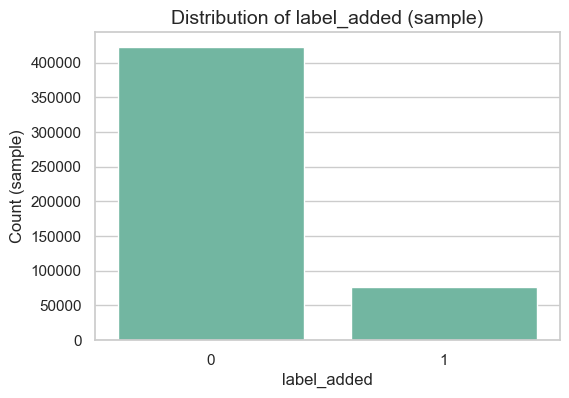

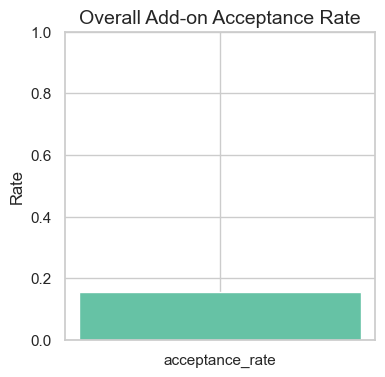

In [15]:
# Target distribution in training data

label_counts = training["label_added"].value_counts().sort_index()
label_pct = (label_counts / len(training)) * 100

print("Label distribution (counts):")
print(label_counts)
print("\nLabel distribution (%):")
print(label_pct)

acceptance_rate = training["label_added"].mean()
print(f"\nOverall acceptance rate (mean label_added): {acceptance_rate:.3f}")

# Bar plot for class imbalance
plt.figure(figsize=(6, 4))
ax = sns.countplot(x="label_added", data=training_sample)
ax.set_title("Distribution of label_added (sample)")
ax.set_xlabel("label_added")
ax.set_ylabel("Count (sample)")
plt.show()

# Optional: visualize acceptance rate as bar
plt.figure(figsize=(4, 4))
plt.bar(["acceptance_rate"], [acceptance_rate])
plt.title("Overall Add-on Acceptance Rate")
plt.ylim(0, 1)
plt.ylabel("Rate")
plt.show()

## SECTION 5 — User Behavior Analysis

We analyze **user-level behavior** using `users` and `sessions`:

- Distribution of `order_frequency`
- Distribution of `recency_days`
- Distribution of `avg_order_value`
- Distribution of `user_segment`
- Sessions per user (from `sessions`)

This helps understand different user cohorts (budget vs premium vs frequent) and their engagement.

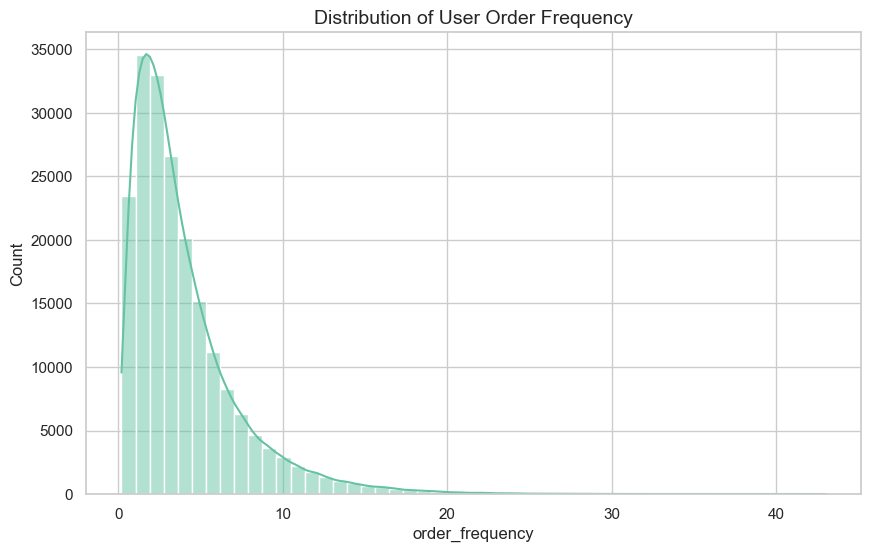

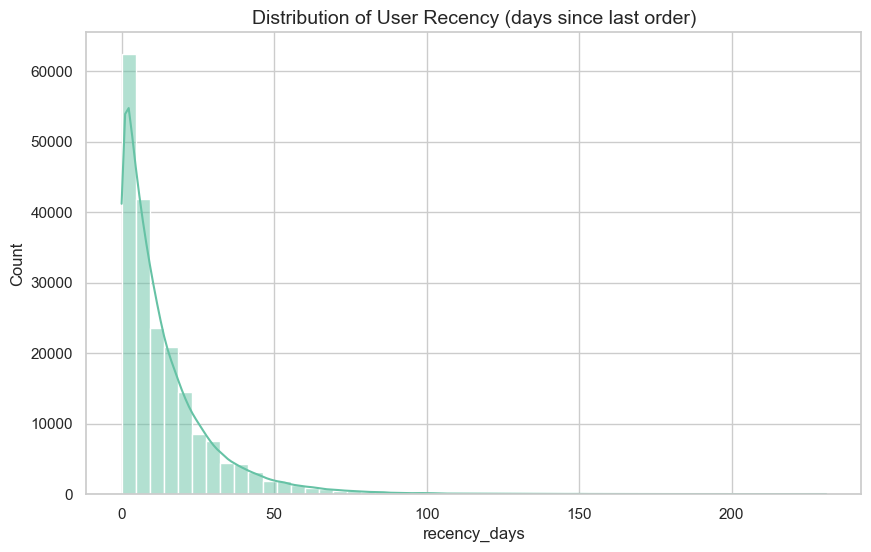

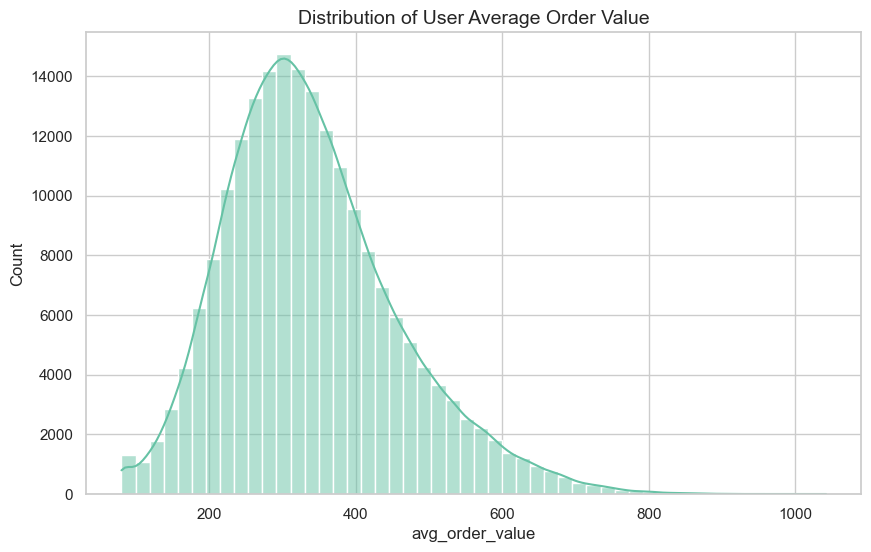

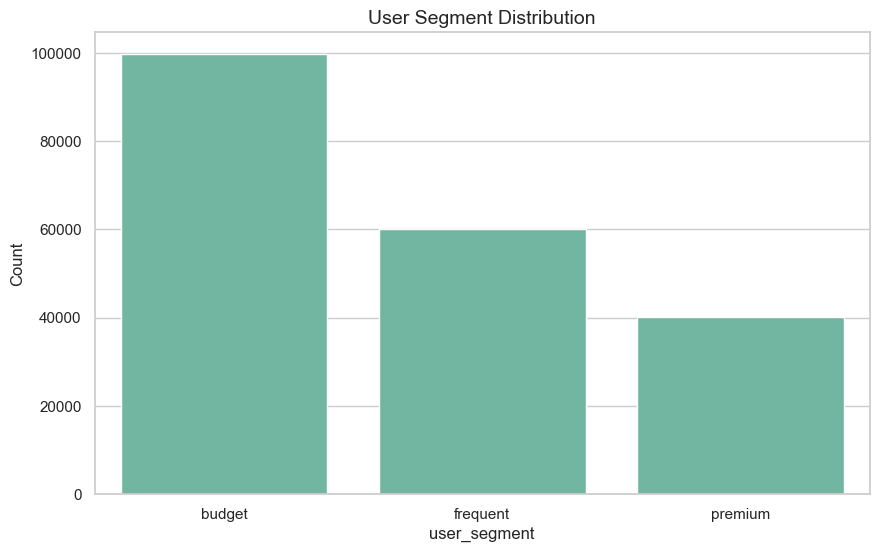

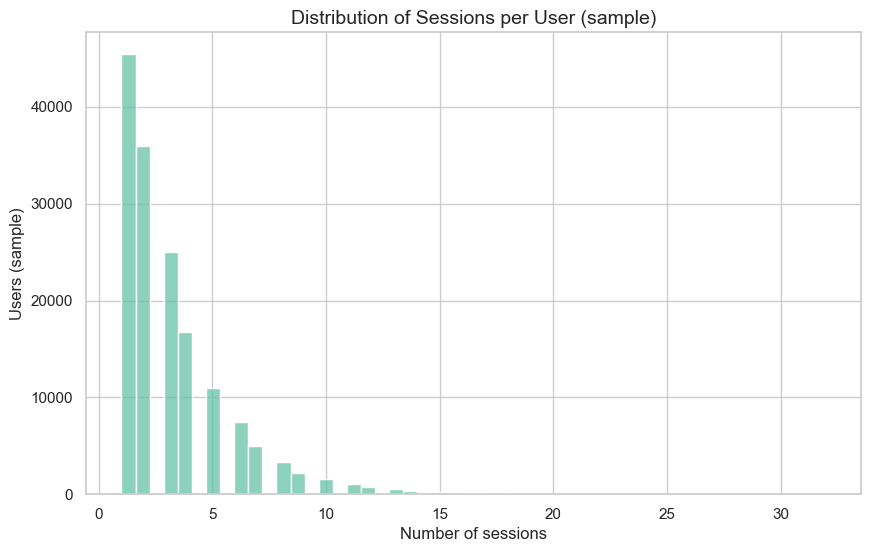

,user_id,num_sessions
count,156951.000000,156951.000000
mean,99992.072449,3.185708
std,57682.371274,2.564044
min,1.000000,1.000000
25%,50065.500000,1.000000
50%,99955.000000,2.000000
75%,149917.500000,4.000000
max,200000.000000,32.000000


In [16]:
# Distribution of order_frequency
plt.figure()
sns.histplot(users["order_frequency"], bins=50, kde=True)
plt.title("Distribution of User Order Frequency")
plt.xlabel("order_frequency")
plt.ylabel("Count")
plt.show()

# Distribution of recency_days
plt.figure()
sns.histplot(users["recency_days"], bins=50, kde=True)
plt.title("Distribution of User Recency (days since last order)")
plt.xlabel("recency_days")
plt.ylabel("Count")
plt.show()

# Distribution of avg_order_value
plt.figure()
sns.histplot(users["avg_order_value"], bins=50, kde=True)
plt.title("Distribution of User Average Order Value")
plt.xlabel("avg_order_value")
plt.ylabel("Count")
plt.show()

# User segment distribution
plt.figure()
sns.countplot(x="user_segment", data=users, order=sorted(users["user_segment"].unique()))
plt.title("User Segment Distribution")
plt.xlabel("user_segment")
plt.ylabel("Count")
plt.show()

# Sessions per user
sessions_per_user = sessions_sample.groupby("user_id")["session_id"].nunique().reset_index(name="num_sessions")

plt.figure()
sns.histplot(sessions_per_user["num_sessions"], bins=50, kde=False)
plt.title("Distribution of Sessions per User (sample)")
plt.xlabel("Number of sessions")
plt.ylabel("Users (sample)")
plt.show()

sessions_per_user.describe()

## SECTION 6 — Restaurant Analysis

We analyze **restaurant-level characteristics** using `restaurants`:

- Cuisine distribution
- Rating distribution
- Price range counts
- Chain vs independent breakdown

These insights help understand supply-side patterns and potential restaurant-level effects on add-on acceptance.

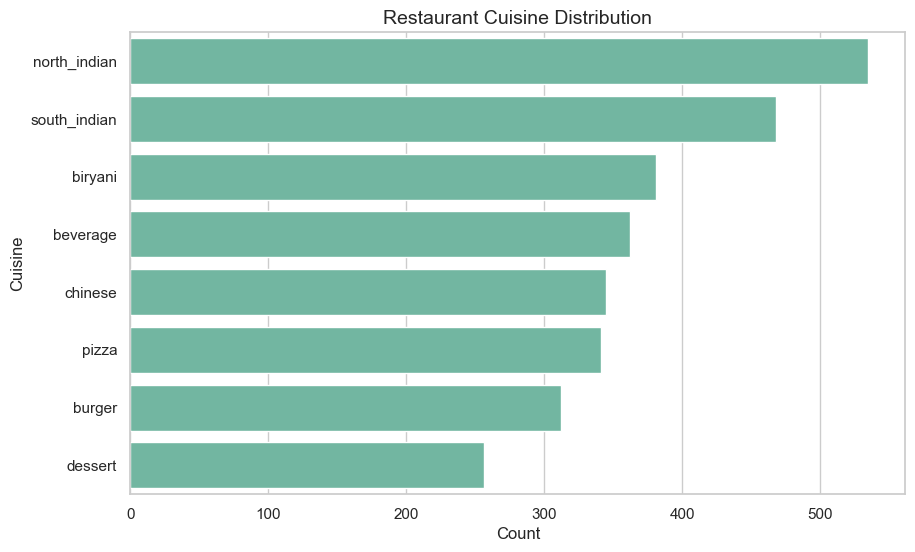

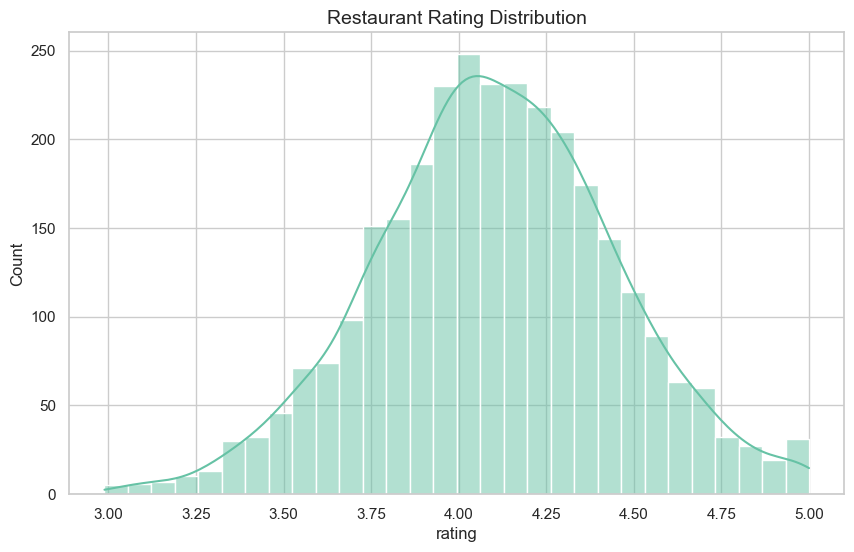

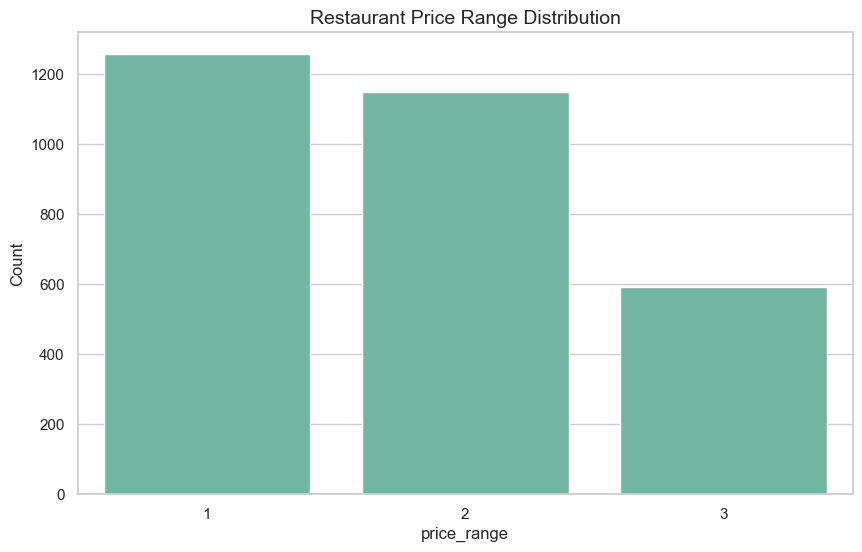


Chain vs Independent (counts):
is_chain
False    2124
True      876
Name: count, dtype: int64


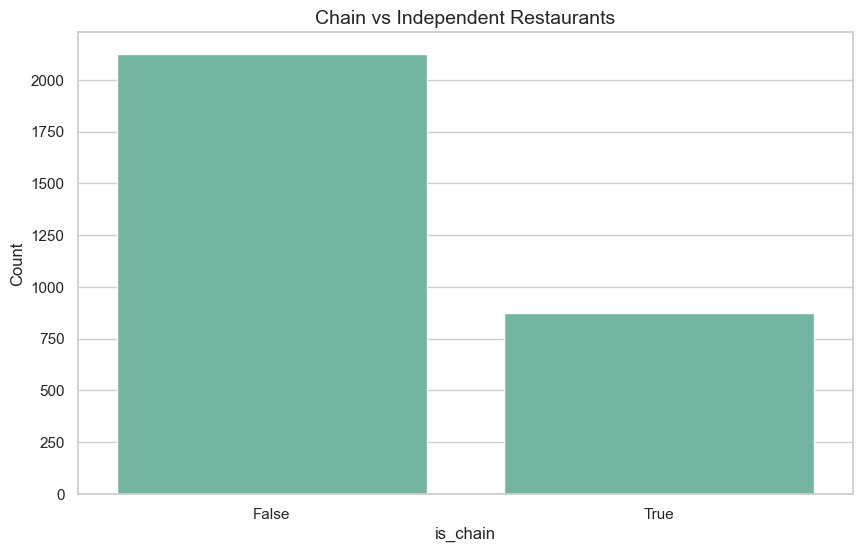

In [17]:
# Cuisine distribution
plt.figure()
sns.countplot(y="cuisine", data=restaurants, order=restaurants["cuisine"].value_counts().index)
plt.title("Restaurant Cuisine Distribution")
plt.xlabel("Count")
plt.ylabel("Cuisine")
plt.show()

# Rating distribution
plt.figure()
sns.histplot(restaurants["rating"], bins=30, kde=True)
plt.title("Restaurant Rating Distribution")
plt.xlabel("rating")
plt.ylabel("Count")
plt.show()

# Price range counts
plt.figure()
sns.countplot(x="price_range", data=restaurants)
plt.title("Restaurant Price Range Distribution")
plt.xlabel("price_range")
plt.ylabel("Count")
plt.show()

# Chain vs independent
restaurants["is_chain_flag"] = restaurants["is_chain"].astype(int)
chain_counts = restaurants["is_chain"].value_counts()
print("\nChain vs Independent (counts):")
print(chain_counts)

plt.figure()
sns.countplot(x="is_chain", data=restaurants)
plt.title("Chain vs Independent Restaurants")
plt.xlabel("is_chain")
plt.ylabel("Count")
plt.show()

## SECTION 7 — Item & Menu Analysis

We analyze **item-level characteristics** using `items`:

- Category distribution
- Price distribution
- Veg vs non-veg ratio
- Popularity distribution

This helps identify which types of items are more common and may act as add-ons.

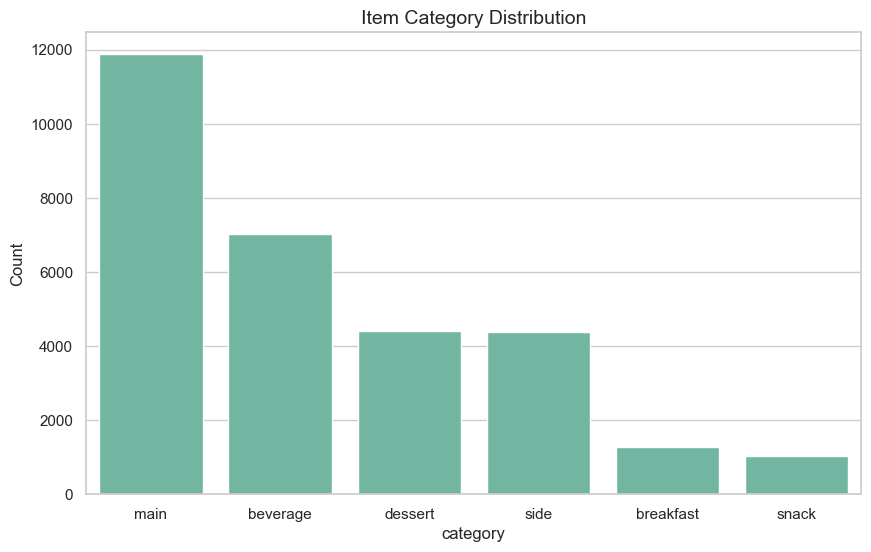

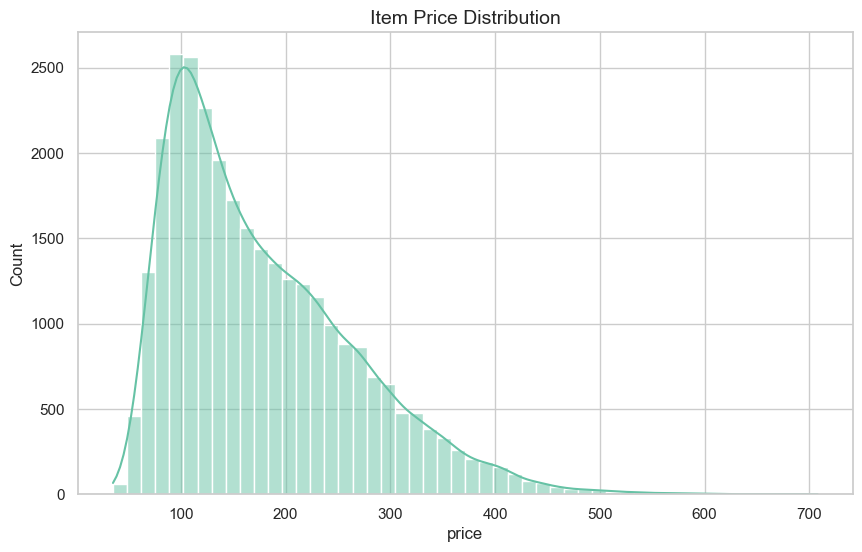

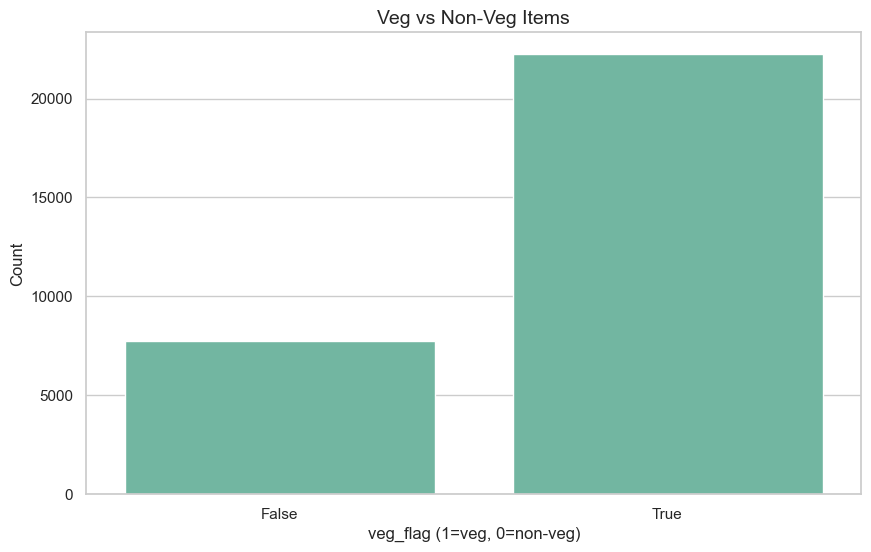

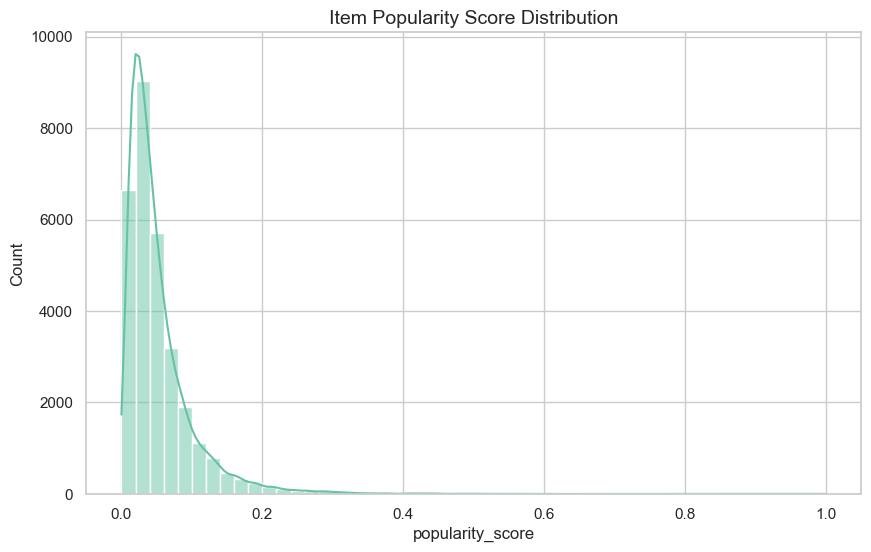

,price,popularity_score
count,30000.000000,30000.000000
mean,177.530899,0.052489
std,88.248009,0.049359
min,35.000000,0.000000
25%,107.451040,0.021714
50%,156.174789,0.038212
75%,230.722572,0.065812
max,707.883301,1.000000


In [18]:
# Category distribution
plt.figure()
sns.countplot(x="category", data=items, order=items["category"].value_counts().index)
plt.title("Item Category Distribution")
plt.xlabel("category")
plt.ylabel("Count")
plt.show()

# Price distribution
plt.figure()
sns.histplot(items["price"], bins=50, kde=True)
plt.title("Item Price Distribution")
plt.xlabel("price")
plt.ylabel("Count")
plt.show()

# Veg vs non-veg ratio
plt.figure()
sns.countplot(x="veg_flag", data=items)
plt.title("Veg vs Non-Veg Items")
plt.xlabel("veg_flag (1=veg, 0=non-veg)")
plt.ylabel("Count")
plt.show()

# Popularity distribution
plt.figure()
sns.histplot(items["popularity_score"], bins=50, kde=True)
plt.title("Item Popularity Score Distribution")
plt.xlabel("popularity_score")
plt.ylabel("Count")
plt.show()

items[["price", "popularity_score"]].describe()

## SECTION 8 — Cart Behavior Analysis

We analyze **cart-level behavior** using `sessions` and `session_items`:

- Cart size distribution (items per session)
- Cart value distribution
- Relationship between cart size and cart value

This helps understand how users build their carts and how add-ons contribute to value.

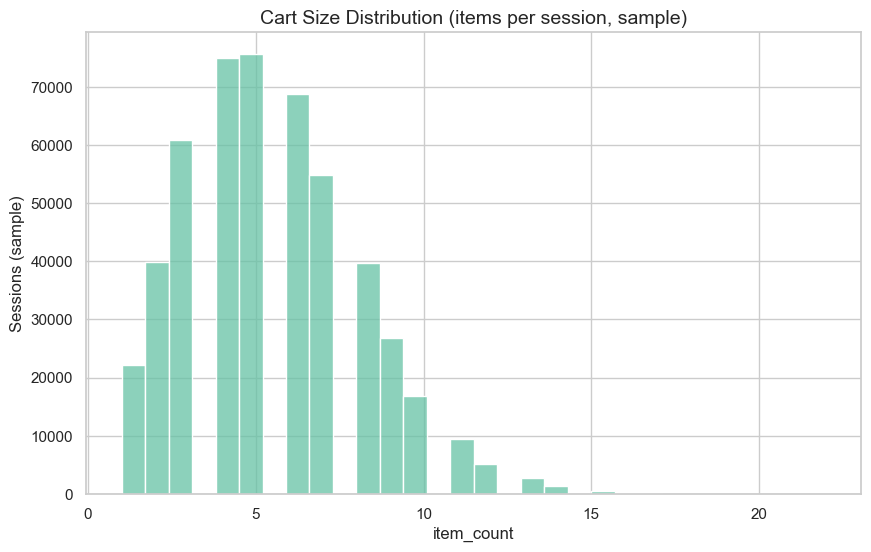

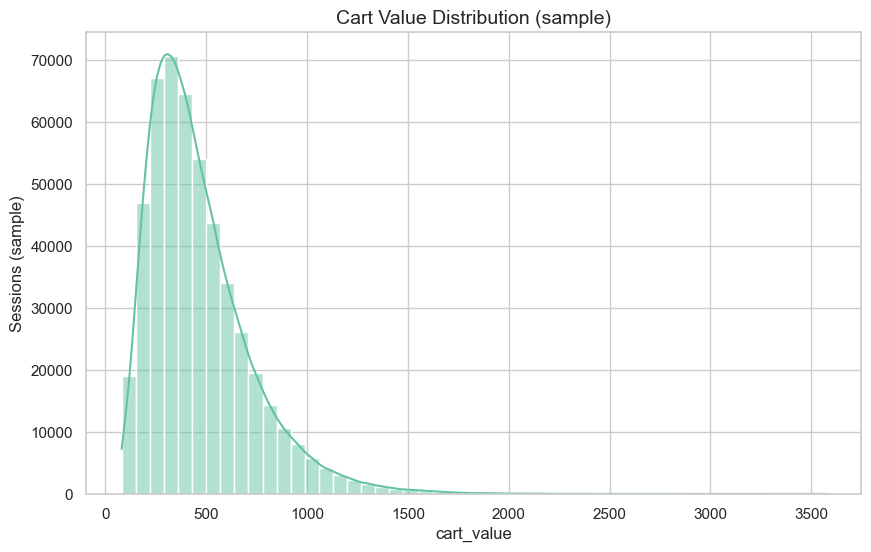

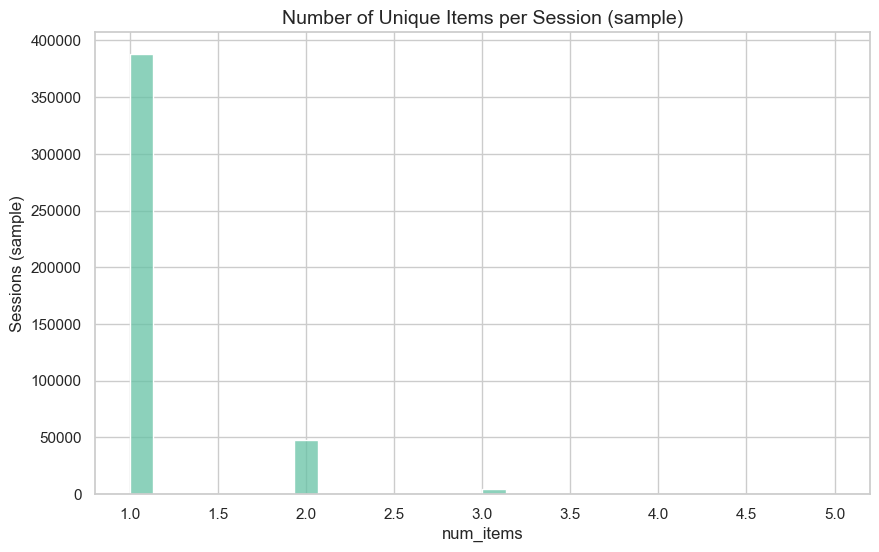

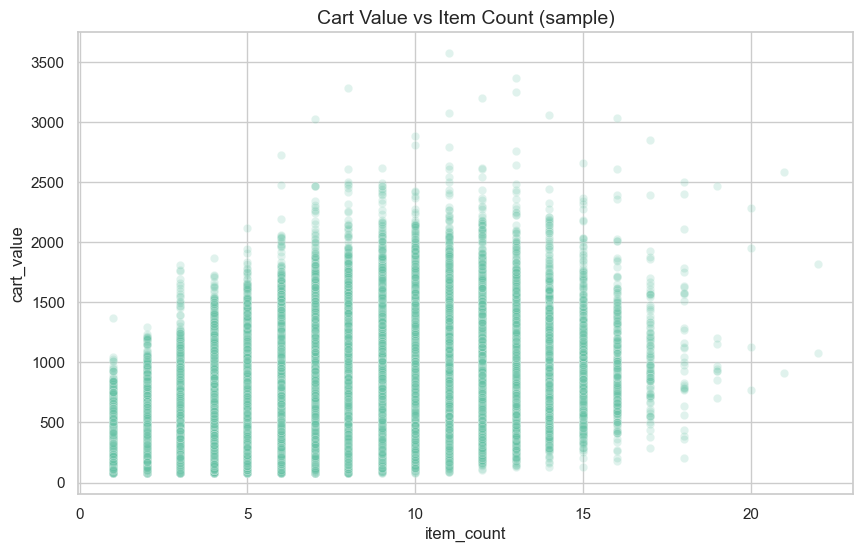

,item_count,cart_value
item_count,1.000000,0.535404
cart_value,0.535404,1.000000


In [19]:
# Cart size distribution (items per session from sessions table)
plt.figure()
sns.histplot(sessions_sample["item_count"], bins=30, kde=False)
plt.title("Cart Size Distribution (items per session, sample)")
plt.xlabel("item_count")
plt.ylabel("Sessions (sample)")
plt.show()

# Cart value distribution
plt.figure()
sns.histplot(sessions_sample["cart_value"], bins=50, kde=True)
plt.title("Cart Value Distribution (sample)")
plt.xlabel("cart_value")
plt.ylabel("Sessions (sample)")
plt.show()

# Items per session from session_items table
items_per_session = (
    session_items_sample.groupby("session_id")["item_id"]
    .nunique()
    .reset_index(name="num_items")
)

plt.figure()
sns.histplot(items_per_session["num_items"], bins=30, kde=False)
plt.title("Number of Unique Items per Session (sample)")
plt.xlabel("num_items")
plt.ylabel("Sessions (sample)")
plt.show()

# Relationship: cart size vs cart value
cart_agg = sessions_sample[["item_count", "cart_value"]].copy()

plt.figure()
sns.scatterplot(x="item_count", y="cart_value", data=cart_agg, alpha=0.2)
plt.title("Cart Value vs Item Count (sample)")
plt.xlabel("item_count")
plt.ylabel("cart_value")
plt.show()

cart_agg.corr(numeric_only=True)

## SECTION 9 — Temporal Analysis

We analyze **temporal patterns** using `sessions`:

- Orders by hour of day
- Orders by day of week
- Meal time distribution (`meal_time`)

These insights capture when users typically order and how that might affect add-on behavior.

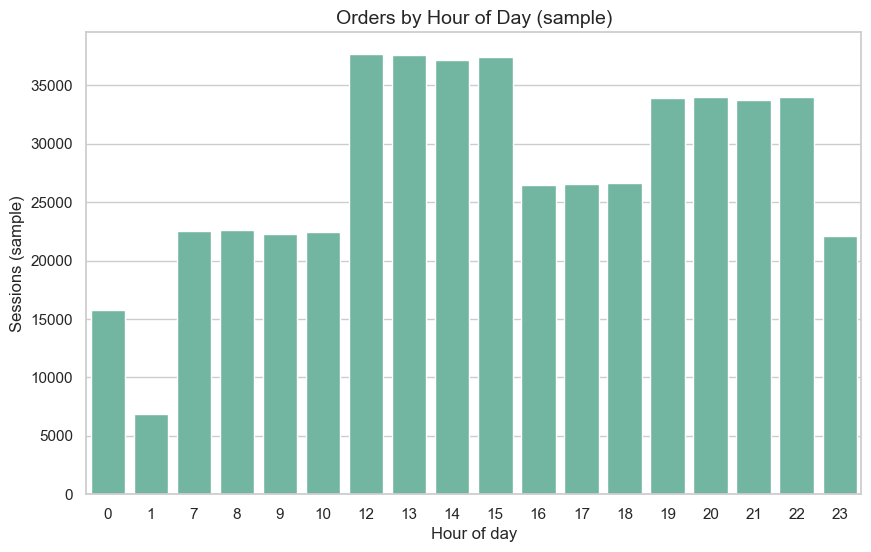

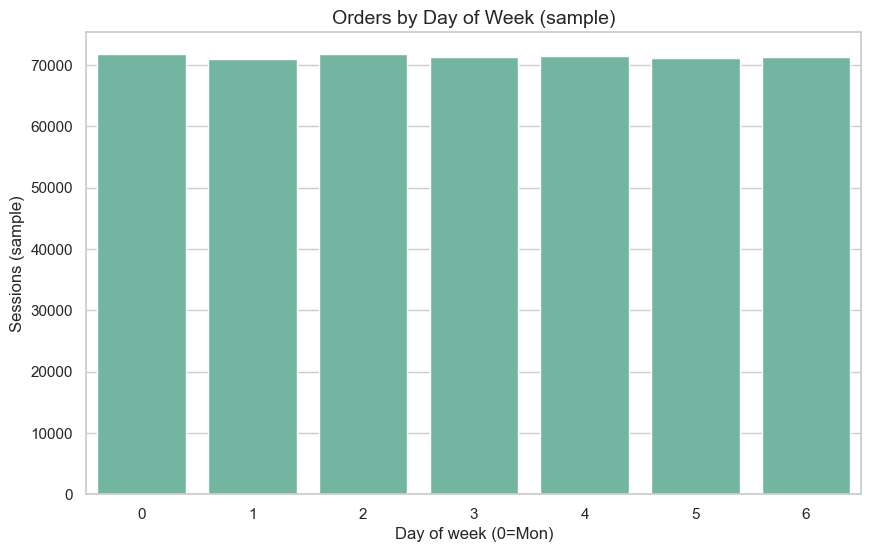

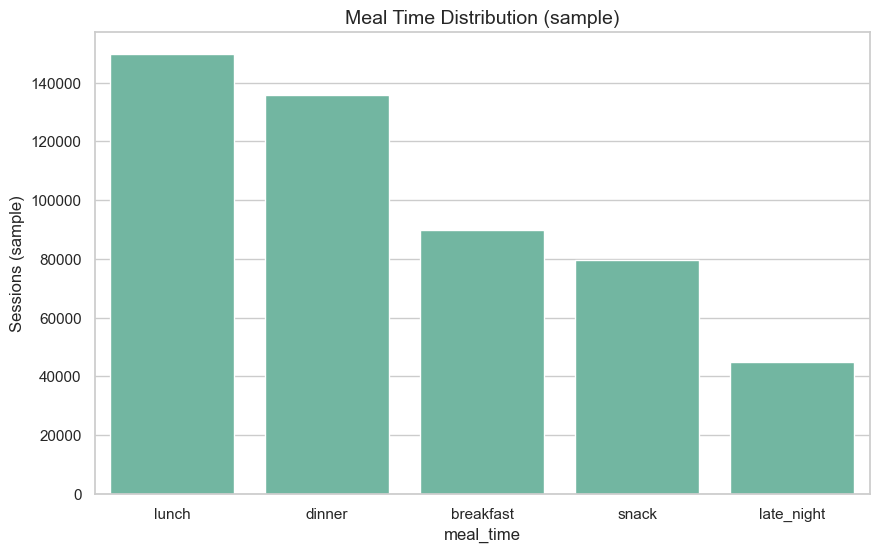

In [20]:
# Orders by hour
plt.figure()
sns.countplot(x="hour", data=sessions_sample)
plt.title("Orders by Hour of Day (sample)")
plt.xlabel("Hour of day")
plt.ylabel("Sessions (sample)")
plt.show()

# Orders by day of week (0=Mon, 6=Sun)
plt.figure()
sns.countplot(x="day_of_week", data=sessions_sample)
plt.title("Orders by Day of Week (sample)")
plt.xlabel("Day of week (0=Mon)")
plt.ylabel("Sessions (sample)")
plt.show()

# Meal time distribution
plt.figure()
sns.countplot(x="meal_time", data=sessions_sample, order=sessions_sample["meal_time"].value_counts().index)
plt.title("Meal Time Distribution (sample)")
plt.xlabel("meal_time")
plt.ylabel("Sessions (sample)")
plt.show()

## SECTION 10 — Candidate Item Behavior

We analyze **candidate-item-level behavior** using `training_dataset`:

- Acceptance rate by candidate item category
- Acceptance rate by candidate price bucket
- Acceptance vs cart value
- Acceptance vs user segment

These analyses reveal which types of items and contexts are associated with higher add-on acceptance.

Acceptance rate by candidate_category (sample):


,candidate_category,acceptance_rate
5,snack,0.337039
1,breakfast,0.189595
2,dessert,0.171137
0,beverage,0.131870
3,main,0.116748
4,side,0.100715


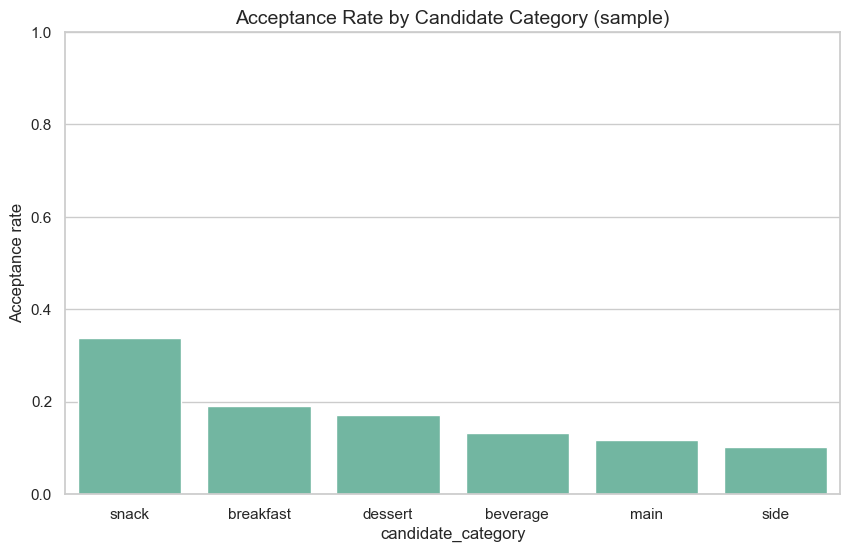

/var/folders/c5/xxndvtvs3tn4lwpcf7845tnh0000gn/T/ipykernel_96442/1465081078.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  training_sample.groupby("candidate_price_bucket")["label_added"]


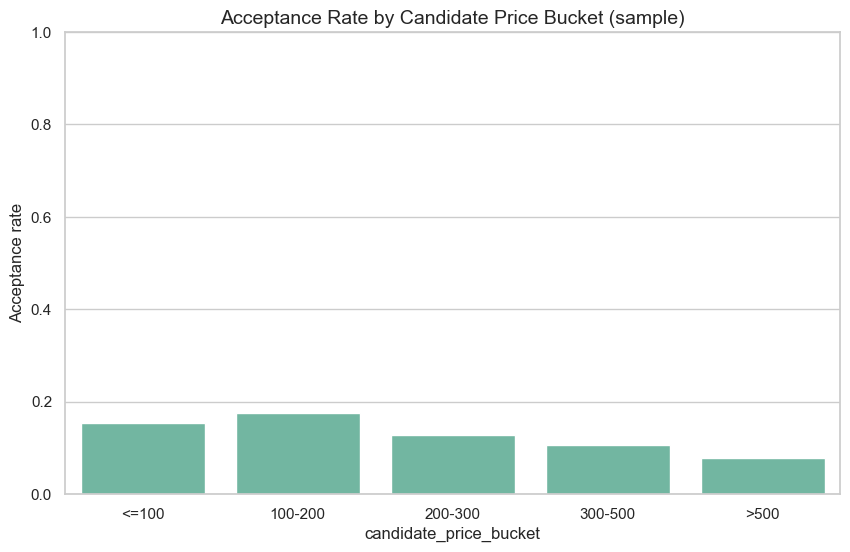

/var/folders/c5/xxndvtvs3tn4lwpcf7845tnh0000gn/T/ipykernel_96442/1465081078.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  training_sample.groupby("cart_value_bucket")["label_added"]


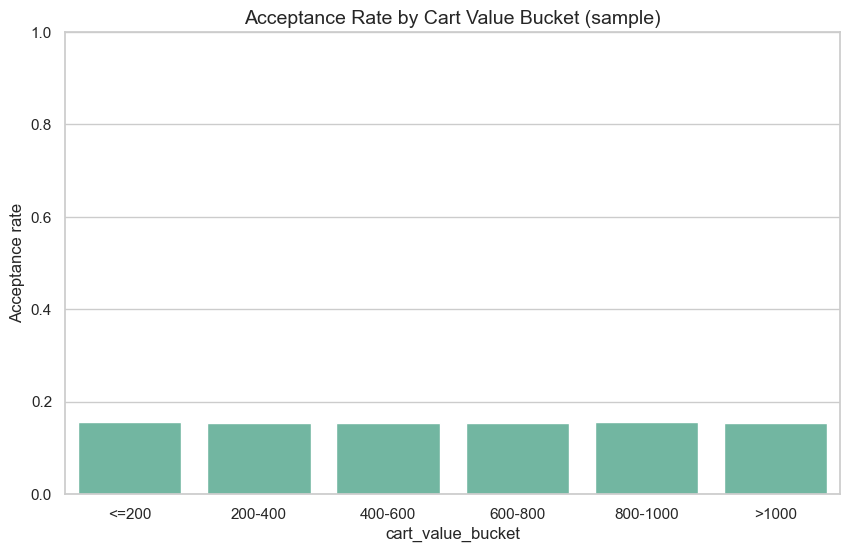

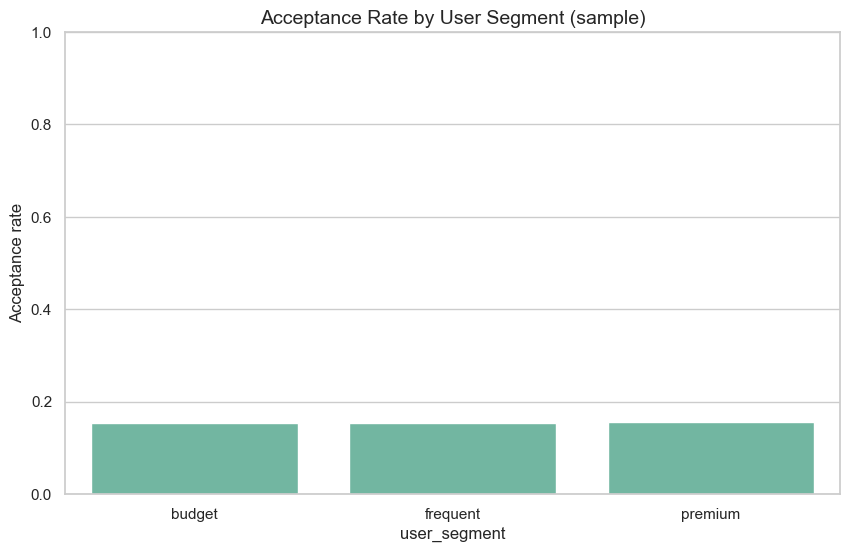

,user_segment,acceptance_rate
0,budget,0.154469
1,frequent,0.153501
2,premium,0.156293


In [21]:
# Acceptance rate by candidate category
cat_accept = (
    training_sample.groupby("candidate_category")["label_added"]
    .mean()
    .reset_index(name="acceptance_rate")
    .sort_values("acceptance_rate", ascending=False)
)
print("Acceptance rate by candidate_category (sample):")
display(cat_accept)

plt.figure()
sns.barplot(x="candidate_category", y="acceptance_rate", data=cat_accept)
plt.title("Acceptance Rate by Candidate Category (sample)")
plt.xlabel("candidate_category")
plt.ylabel("Acceptance rate")
plt.ylim(0, 1)
plt.show()

# Acceptance rate by candidate price bucket
price_bins = [0, 100, 200, 300, 500, np.inf]
price_labels = ["<=100", "100-200", "200-300", "300-500", ">500"]
training_sample["candidate_price_bucket"] = pd.cut(
    training_sample["candidate_price"], bins=price_bins, labels=price_labels, right=True
)

price_accept = (
    training_sample.groupby("candidate_price_bucket")["label_added"]
    .mean()
    .reset_index(name="acceptance_rate")
)

plt.figure()
sns.barplot(x="candidate_price_bucket", y="acceptance_rate", data=price_accept)
plt.title("Acceptance Rate by Candidate Price Bucket (sample)")
plt.xlabel("candidate_price_bucket")
plt.ylabel("Acceptance rate")
plt.ylim(0, 1)
plt.show()

# Acceptance vs cart value (binned)
cart_bins = [0, 200, 400, 600, 800, 1_000, np.inf]
cart_labels = ["<=200", "200-400", "400-600", "600-800", "800-1000", ">1000"]
training_sample["cart_value_bucket"] = pd.cut(
    training_sample["cart_value"], bins=cart_bins, labels=cart_labels, right=True
)

cart_accept = (
    training_sample.groupby("cart_value_bucket")["label_added"]
    .mean()
    .reset_index(name="acceptance_rate")
)

plt.figure()
sns.barplot(x="cart_value_bucket", y="acceptance_rate", data=cart_accept)
plt.title("Acceptance Rate by Cart Value Bucket (sample)")
plt.xlabel("cart_value_bucket")
plt.ylabel("Acceptance rate")
plt.ylim(0, 1)
plt.show()

# Acceptance vs user segment
seg_accept = (
    training_sample.groupby("user_segment")["label_added"]
    .mean()
    .reset_index(name="acceptance_rate")
)

plt.figure()
sns.barplot(x="user_segment", y="acceptance_rate", data=seg_accept)
plt.title("Acceptance Rate by User Segment (sample)")
plt.xlabel("user_segment")
plt.ylabel("Acceptance rate")
plt.ylim(0, 1)
plt.show()

seg_accept

## SECTION 11 — Correlation Analysis

We compute and visualize correlations between key numerical features from the training dataset:

Example features:

- `cart_value`, `item_count`
- `candidate_price`, `candidate_popularity`
- Encoded `label_added`

This helps understand linear relationships and potential multicollinearity between predictors and the target.

Correlation matrix (sample):


,cart_value,item_count,hour,candidate_price,candidate_popularity,label_added
cart_value,1.000000,0.515713,0.260603,0.033192,-0.000573,-0.001438
item_count,0.515713,1.000000,0.205793,0.014254,-0.000636,-0.001898
hour,0.260603,0.205793,1.000000,0.046240,-0.004216,-0.002647
candidate_price,0.033192,0.014254,0.046240,1.000000,-0.017755,-0.054950
candidate_popularity,-0.000573,-0.000636,-0.004216,-0.017755,1.000000,-0.008092
label_added,-0.001438,-0.001898,-0.002647,-0.054950,-0.008092,1.000000


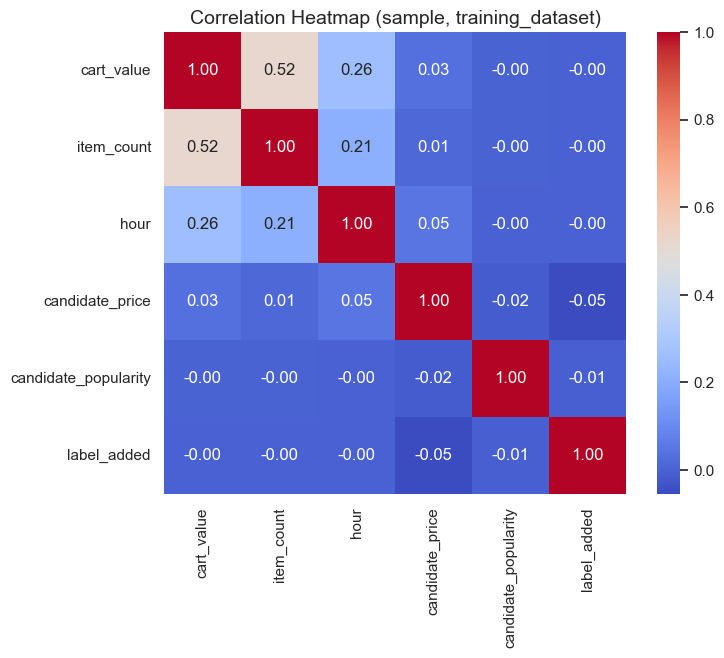

In [22]:
# Select numerical columns for correlation analysis
num_cols_corr = [
    "cart_value",
    "item_count",
    "hour",
    "candidate_price",
    "candidate_popularity",
    "label_added",
]

corr_df = training_sample[num_cols_corr].copy()

corr_matrix = corr_df.corr(numeric_only=True)
print("Correlation matrix (sample):")
display(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap (sample, training_dataset)")
plt.show()

## SECTION 12 — Key Insights Summary (Updated)

This summary captures concrete insights from the generated CSAO datasets and highlights immediate modeling implications.

### 1. Scale and Coverage

- Users: **200,000**
- Restaurants: **3,000**
- Items: **30,000**
- Sessions: **2,000,000**
- Session-items: **10,893,100**
- Processed ranking rows (`ranking_dataset`): **36,755,348**

Interpretation:
- Scale is sufficient for retrieval + ranking experiments and segment-level evaluation.
- Candidate pool is large enough to test recall/latency trade-offs.

### 2. User and Demand Distribution

- User segment mix is moderately imbalanced:
  - `budget`: ~49.88%
  - `frequent`: ~30.05%
  - `premium`: ~20.07%
- Mean user order frequency: **3.97**
- Mean user AOV: **339.88**
- Median recency: **9 days**

Interpretation:
- Segment-conditioned modeling is necessary (especially pricing sensitivity and premium upsell behavior).
- Recency is relatively fresh overall, so temporal weighting should help ranking.

### 3. Catalog Structure

- Top restaurant cuisines: `north_indian`, `south_indian`, `biryani`, `beverage`, `chinese`
- Mean restaurant rating: **4.10**
- Chain share: **29.2%**
- Item category mix is main-heavy (`main` dominates), followed by `beverage`, `dessert`, `side`.
- Mean item price: **177.53**
- Veg share: **74.2%**

Interpretation:
- Strong category prior exists; model should avoid over-serving `main` by using add-on-aware features.
- Veg/non-veg imbalance should be handled in evaluation slices.

### 4. Cart and Temporal Behavior

- Mean cart value: **464.44**
- Mean items per session: **5.45**
- Quantity p95 per line item: **2**
- Meal-time mix:
  - `lunch`: 30.01%
  - `dinner`: 27.07%
  - `breakfast`: 18.00%
  - `snack`: 15.94%
  - `late_night`: 8.99%
- Hourly peaks are concentrated in lunch and early evening windows.

Interpretation:
- Session-context features (`meal_time`, `hour`, `cart_value`, `item_count`) are high-signal and should remain core features.

### 5. Label and Candidate Dynamics

- Positive rate in processed `ranking_dataset` (`label_added`): **15.41%**
- Sessions with at least one positive in `ranking_dataset`: **~100%**
- Acceptance by candidate category is highest for `snack` and `dessert` (relative to other categories).

Interpretation:
- Add-on objective is meaningful (not ultra-sparse), but calibration is still important due to class imbalance.
- Category-aware candidate generation remains valuable.

### 6. Critical Data Quality Alert

A critical issue was observed in current `featured` validation/test files:
- `val_ranking_features.parquet`: only class `0`
- `test_ranking_features.parquet`: only class `0`

Impact:
- Ranking metrics on these splits become invalid or near-zero/NaN for recall-style evaluation.
- Baseline/neural comparisons can be misleading if run on these files directly.

Action required before final evaluation:
- Rebuild `featured` splits from a correct labeled source (or enforce fallback to processed labeled data).
- Add split-level label assertions in all training/evaluation scripts.

### 7. Recommended Next Modeling Actions

1. Enforce hard data checks (label variance, positives/session) before training.
2. Keep leaky-feature filtering enabled in baseline pipelines.
3. Evaluate metrics by segment (`meal_time`, `user_segment`, `category`) in addition to global NDCG.
4. Use candidate-recall diagnostics to separate retrieval bottlenecks from ranking bottlenecks.
5. Re-run baselines and neural ranking only on validated splits.



In [23]:
# SECTION 13 — Quick Numeric Insight Table (Auto)

from pathlib import Path

base = PROJECT_ROOT / "data_pipeline" / "data"
featured_dir = base / "featured"

quick_stats = {
    "users": len(users),
    "restaurants": len(restaurants),
    "items": len(items),
    "sessions": len(sessions),
    "session_items": len(session_items),
    "interactions": len(interactions),
    "ranking_rows": len(ranking_data),
    "user_order_frequency_mean": float(users["order_frequency"].mean()),
    "user_aov_mean": float(users["avg_order_value"].mean()),
    "session_cart_value_mean": float(sessions["cart_value"].mean()),
    "session_item_count_mean": float(sessions["item_count"].mean()),
    "ranking_label_rate": float(ranking_data["label_added"].mean()) if "label_added" in ranking_data.columns else np.nan,
}

quick_stats_df = pd.DataFrame(
    {"metric": list(quick_stats.keys()), "value": list(quick_stats.values())}
)
quick_stats_df



,metric,value
0,users,2.000000e+05
1,restaurants,3.000000e+03
2,items,3.000000e+04
3,sessions,2.000000e+06
4,session_items,1.089310e+07
5,interactions,1.089310e+07
6,ranking_rows,3.675535e+07
7,user_order_frequency_mean,3.969228e+00
8,user_aov_mean,3.398847e+02
9,session_cart_value_mean,4.644399e+02


## SECTION 14 — Featured Split Label Sanity Check

Run the next cell to verify class balance in `data_pipeline/data/featured/*`.
If val/test have no positives, do not use them for final model reporting.



In [24]:
featured_label_stats = []
for split_name in ["train", "val", "test"]:
    p = featured_dir / f"{split_name}_ranking_features.parquet"
    if p.exists():
        tmp = pd.read_parquet(p, columns=["label"])
        vc = tmp["label"].value_counts(dropna=False).to_dict()
        featured_label_stats.append(
            {
                "split": split_name,
                "rows": len(tmp),
                "positive_count": int(vc.get(1, 0)),
                "negative_count": int(vc.get(0, 0)),
                "positive_rate": float(tmp["label"].mean()) if len(tmp) else np.nan,
                "distinct_label_values": len(vc),
            }
        )

pd.DataFrame(featured_label_stats)



,split,rows,positive_count,negative_count,positive_rate,distinct_label_values
0,train,146864273,6864173,140000100,0.046738,2
1,val,30001100,0,30001100,0.000000,1
2,test,29998800,0,29998800,0.000000,1
